# Netflix Data Analysis

## Analyse exploratoire du catalogue Netflix (septembre 2021)

---

### Sommaire

1. Chargement et aperçu des données
2. Exploration de la structure du DataFrame
3. Données manquantes
4. Recherche et filtrage
5. Nettoyage et transformation des données
6. Analyse descriptive
7. Visualisations
8. Observations et conclusions

---
## 1. Chargement et aperçu des données

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration générale
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Question 3 : Chargement du dataset
df = pd.read_csv('netflix_titles.csv')
print(f"Dataset chargé avec succès : {df.shape[0]} lignes, {df.shape[1]} colonnes")


Dataset chargé avec succès : 8807 lignes, 12 colonnes


In [37]:
# Question 4 : Aperçu des 5 premières et 5 dernières observations
print("═" * 60)
print("5 PREMIÈRES LIGNES")
print("═" * 60)
display(df.head())

print("\n" + "═" * 60)
print("5 DERNIÈRES LIGNES")
print("═" * 60)
display(df.tail())


════════════════════════════════════════════════════════════
5 PREMIÈRES LIGNES
════════════════════════════════════════════════════════════


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



════════════════════════════════════════════════════════════
5 DERNIÈRES LIGNES
════════════════════════════════════════════════════════════


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


---
## 2. Exploration de la structure du DataFrame

In [38]:
# Question 5 : Informations du DataFrame (type d'index, colonnes, valeurs non nulles, mémoire)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [39]:
# Question 6 : Dimensionnalité du DataFrame
print(f"Dimensions : {df.shape}")
print(f"Nombre d'observations (lignes) : {df.shape[0]}")
print(f"Nombre de variables (colonnes) : {df.shape[1]}")


Dimensions : (8807, 12)
Nombre d'observations (lignes) : 8807
Nombre de variables (colonnes) : 12


In [40]:
# Question 7 : Colonnes du DataFrame
print("Colonnes du DataFrame :")
print(list(df.columns))


Colonnes du DataFrame :
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [41]:
# Question 8 : Type des différentes colonnes
print("Types des colonnes :")
print(df.dtypes)

print("\n--- Analyse ---")
print("Données quantitatives (numériques) : release_year (int64), show_id (object mais identifiant)")
print("Données qualitatives (catégorielles) : type, title, director, cast, country, date_added, rating, duration, listed_in, description")


Types des colonnes :
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

--- Analyse ---
Données quantitatives (numériques) : release_year (int64), show_id (object mais identifiant)
Données qualitatives (catégorielles) : type, title, director, cast, country, date_added, rating, duration, listed_in, description


---
## 3. Données manquantes

In [42]:
# Question 9 : Données manquantes — proportion en pourcentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print("Pourcentage de données manquantes par colonne :")
print(missing_percentage.round(2))


Pourcentage de données manquantes par colonne :
director      29.91
country        9.44
cast           9.37
date_added     0.11
rating         0.05
duration       0.03
dtype: float64


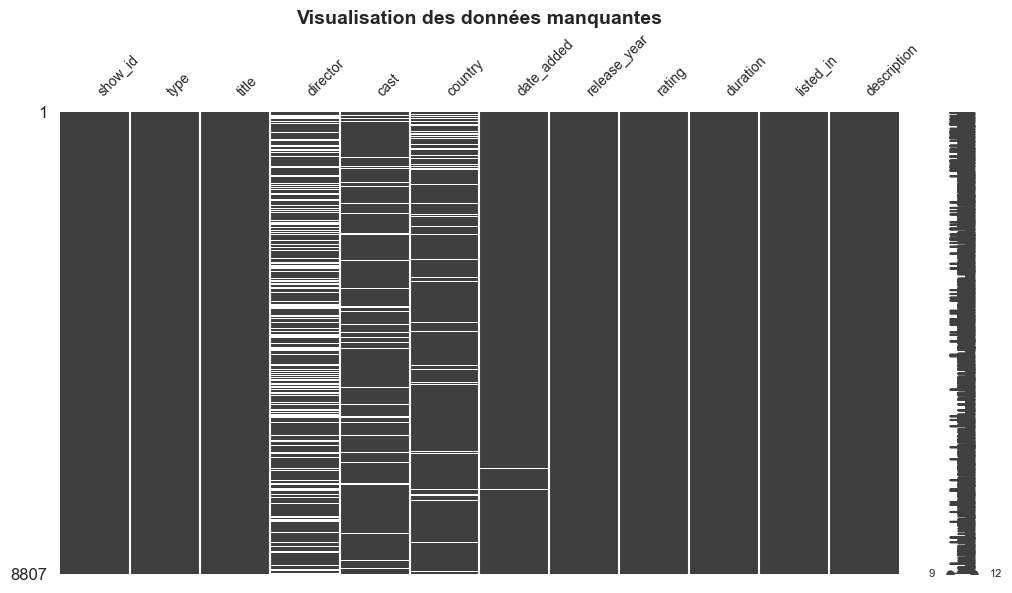

In [43]:
# Question 10 : Graphique missingno des données manquantes
msno.matrix(df, figsize=(12, 6), fontsize=10)
plt.title("Visualisation des données manquantes", fontsize=14, fontweight='bold')
plt.show()


---
## 4. Recherche et filtrage

In [44]:
# Question 11 : Observation aléatoire
df.sample(1)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1636,s1637,Movie,Dance Dreams: Hot Chocolate Nutcracker,Oliver Bokelberg,Debbie Allen,United States,"November 27, 2020",2020,TV-PG,81 min,"Children & Family Movies, Documentaries",This documentary spotlights Debbie Allen's car...


In [45]:
# Question 12 : Toutes les informations de "Catch Me If You Can"
df[df['title'] == 'Catch Me If You Can']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
329,s330,Movie,Catch Me If You Can,Steven Spielberg,"Leonardo DiCaprio, Tom Hanks, Christopher Walk...","United States, Canada","August 1, 2021",2002,PG-13,142 min,Dramas,An FBI agent makes it his mission to put cunni...


In [46]:
# Question 13 : Film le plus récent du dataset
most_recent_movie = df[df['type'] == 'Movie'].sort_values('release_year', ascending=False).iloc[0]
print(f"Film le plus récent : {most_recent_movie['title']} ({most_recent_movie['release_year']})")


Film le plus récent : My Heroes Were Cowboys (2021)


In [47]:
# Question 14 : Série la plus récente du dataset
most_recent_show = df[df['type'] == 'TV Show'].sort_values('release_year', ascending=False).iloc[0]
print(f"Série la plus récente : {most_recent_show['title']} ({most_recent_show['release_year']})")


Série la plus récente : Metal Shop Masters (2021)


---
## 5. Nettoyage et transformation des données

In [48]:
# Question 15 : Conversion de date_added en DateTime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
print(f"Type de date_added : {df['date_added'].dtype}")
df[['title', 'date_added']].head()


Type de date_added : datetime64[us]


,title,date_added
0,Dick Johnson Is Dead,2021-09-25
1,Blood & Water,2021-09-24
2,Ganglands,2021-09-24
3,Jailbirds New Orleans,2021-09-24
4,Kota Factory,2021-09-24


In [49]:
# Question 16 : Durée des films en nombre (ex: 160 au lieu de "160 min")
movies_mask = df['type'] == 'Movie'
df.loc[movies_mask, 'duration_clean'] = df.loc[movies_mask, 'duration'].str.extract(r'(\d+)')[0].astype(float)

print("Vérification pour les films :")
df.loc[movies_mask, ['title', 'duration', 'duration_clean']].head()


Vérification pour les films :


,title,duration,duration_clean
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0


In [50]:
# Question 17 : Durée des séries en nombre (ex: 2 au lieu de "2 Seasons")
shows_mask = df['type'] == 'TV Show'
df.loc[shows_mask, 'duration_clean'] = df.loc[shows_mask, 'duration'].str.extract(r'(\d+)')[0].astype(float)

print("Vérification pour les séries :")
df.loc[shows_mask, ['title', 'duration', 'duration_clean']].head()


Vérification pour les séries :


,title,duration,duration_clean
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0


In [51]:
# Question 18 : Transformation de listed_in en liste de chaînes
df['listed_in'] = df['listed_in'].str.split(', ')

print("Exemple :")
print(df['listed_in'].iloc[0])


Exemple :
['Documentaries']


---
## 6. Analyse descriptive

In [52]:
# Question 19 : Valeurs uniques des variables type, country, release_year, rating et listed_in
print("=== Types d'oeuvres ===")
print(df['type'].unique())

print("\n=== Pays (10 premiers) ===")
print(df['country'].dropna().unique()[:10])

print("\n=== Années de sortie ===")
print(sorted(df['release_year'].unique()))

print("\n=== Ratings ===")
print(df['rating'].dropna().unique())

print("\n=== Genres (10 premiers) ===")
all_genres = df['listed_in'].explode().str.strip().unique()
print(all_genres[:10])
print(f"\nNombre total de genres uniques : {len(all_genres)}")


=== Types d'oeuvres ===
<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

=== Pays (10 premiers) ===
<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
                                          'United States, India, France']
Length: 10, dtype: str

=== Années de sortie ===
[np.int64(1925), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1945), np.int6

In [53]:
# Question 20 : Directors ayant produit plus d'une oeuvre
directors_counts = df['director'].dropna().value_counts()
multi_directors = directors_counts[directors_counts > 1]
print(f"Nombre de réalisateurs avec plus d'une oeuvre : {len(multi_directors)}\n")
print("Top 15 des réalisateurs les plus prolifiques :")
print(multi_directors.head(15))


Nombre de réalisateurs avec plus d'une oeuvre : 867

Top 15 des réalisateurs les plus prolifiques :
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Quentin Tarantino          8
Robert Rodriguez           8
Yılmaz Erdoğan             8
Name: count, dtype: int64


In [54]:
# Question 21 : Année avec le plus de films ajoutés au catalogue
movies = df[df['type'] == 'Movie']
year_movies = movies['date_added'].dt.year.value_counts()
print(f"Année record pour les films : {int(year_movies.idxmax())} ({int(year_movies.max())} films ajoutés)")


Année record pour les films : 2019 (1424 films ajoutés)


In [55]:
# Question 22 : Année avec le plus de séries ajoutées au catalogue
shows = df[df['type'] == 'TV Show']
year_shows = shows['date_added'].dt.year.value_counts()
print(f"Année record pour les séries : {int(year_shows.idxmax())} ({int(year_shows.max())} séries ajoutées)")


Année record pour les séries : 2020 (595 séries ajoutées)


---
## 7. Visualisations

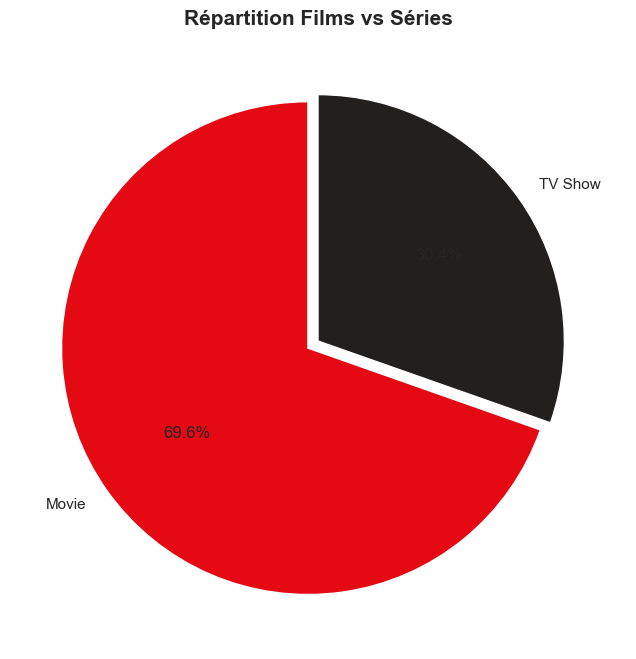

In [56]:
# Question 23a : Répartition du type d'oeuvres
plt.figure(figsize=(8, 8))
df['type'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#E50914', '#221f1f'],
    startangle=90,
    explode=(0.05, 0)
)
plt.title('Répartition Films vs Séries', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.show()


C:\Users\btyma\AppData\Local\Temp\ipykernel_30796\1083614784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


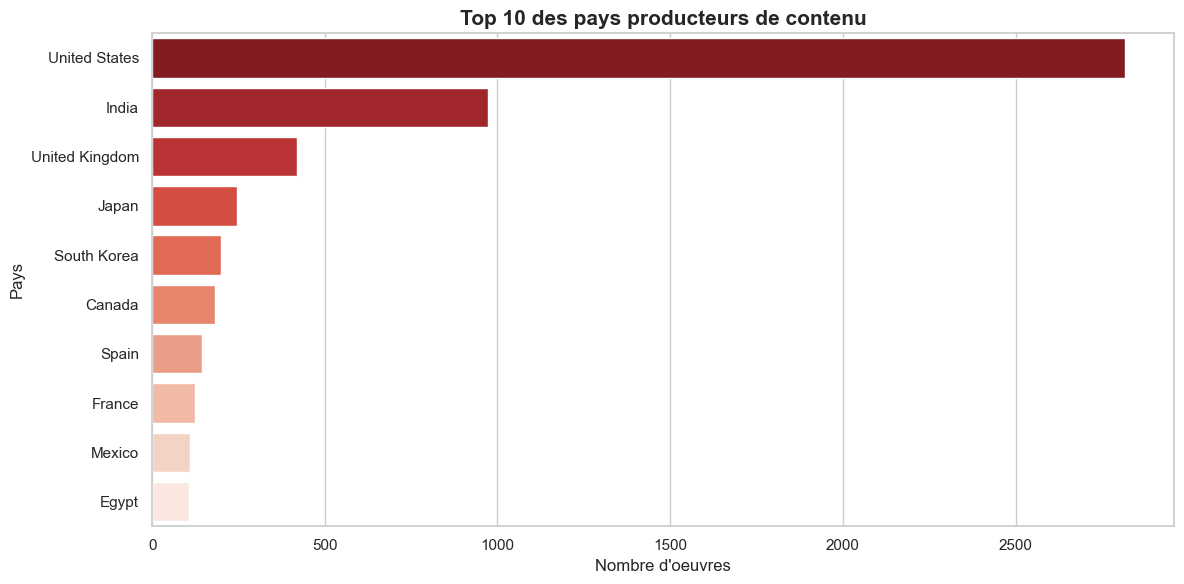

In [57]:
# Question 23b : Répartition des oeuvres par pays (Top 10)
plt.figure(figsize=(12, 6))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 des pays producteurs de contenu', fontsize=15, fontweight='bold')
plt.xlabel("Nombre d'oeuvres")
plt.ylabel('Pays')
plt.tight_layout()
plt.show()


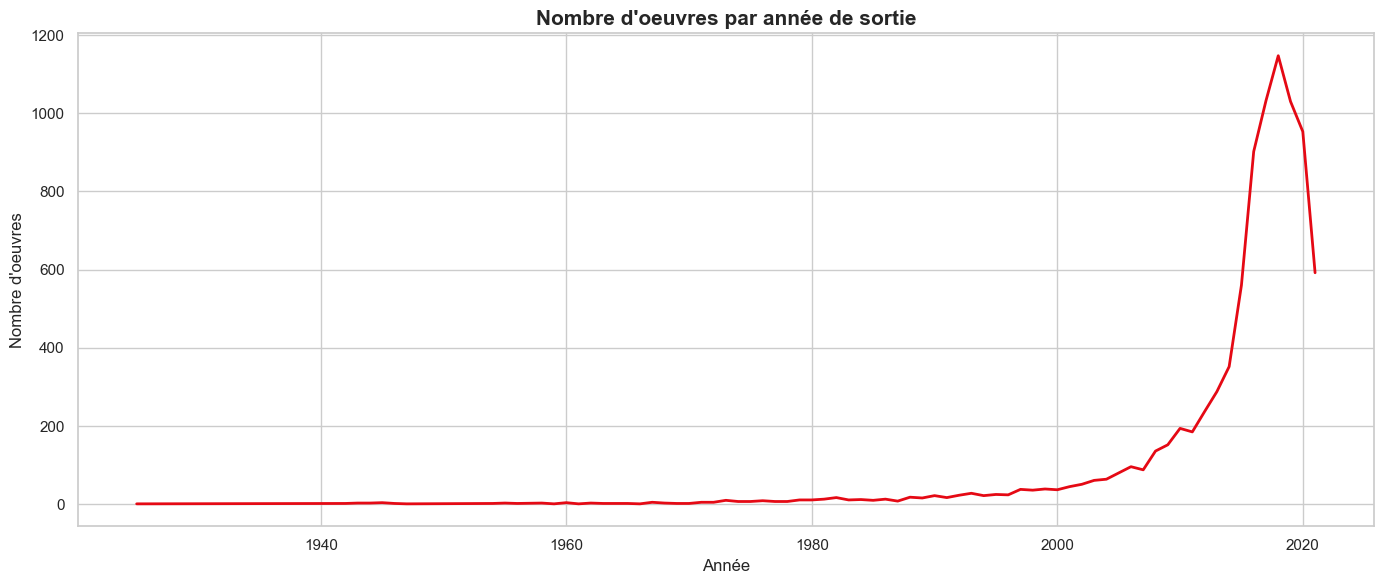

In [58]:
# Question 23c : Répartition des oeuvres par année de sortie
plt.figure(figsize=(14, 6))
df['release_year'].value_counts().sort_index().plot(kind='line', color='#E50914', linewidth=2)
plt.title('Nombre d\'oeuvres par année de sortie', fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel("Nombre d'oeuvres")
plt.tight_layout()
plt.show()


C:\Users\btyma\AppData\Local\Temp\ipykernel_30796\1817884137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='magma')


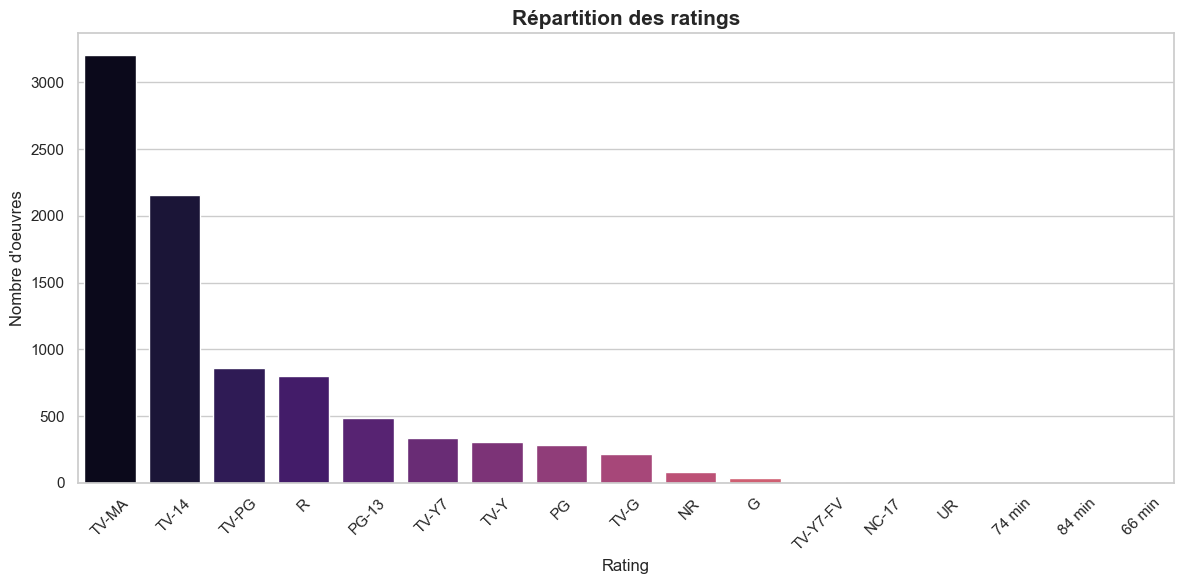

In [59]:
# Question 23d : Répartition des ratings
plt.figure(figsize=(12, 6))
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='magma')
plt.title('Répartition des ratings', fontsize=15, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel("Nombre d'oeuvres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


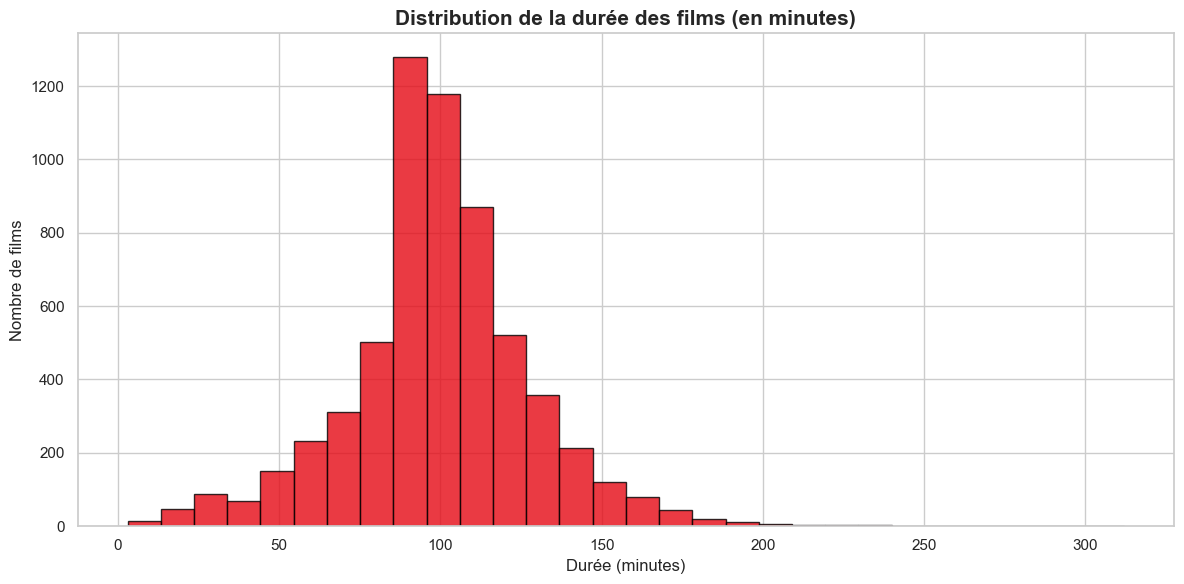

In [60]:
# Question 23e : Répartition de la durée des films
movies_duration = df[df['type'] == 'Movie']['duration_clean'].dropna()
plt.figure(figsize=(12, 6))
plt.hist(movies_duration, bins=30, color='#E50914', edgecolor='black', alpha=0.8)
plt.title('Distribution de la durée des films (en minutes)', fontsize=15, fontweight='bold')
plt.xlabel('Durée (minutes)')
plt.ylabel('Nombre de films')
plt.tight_layout()
plt.show()


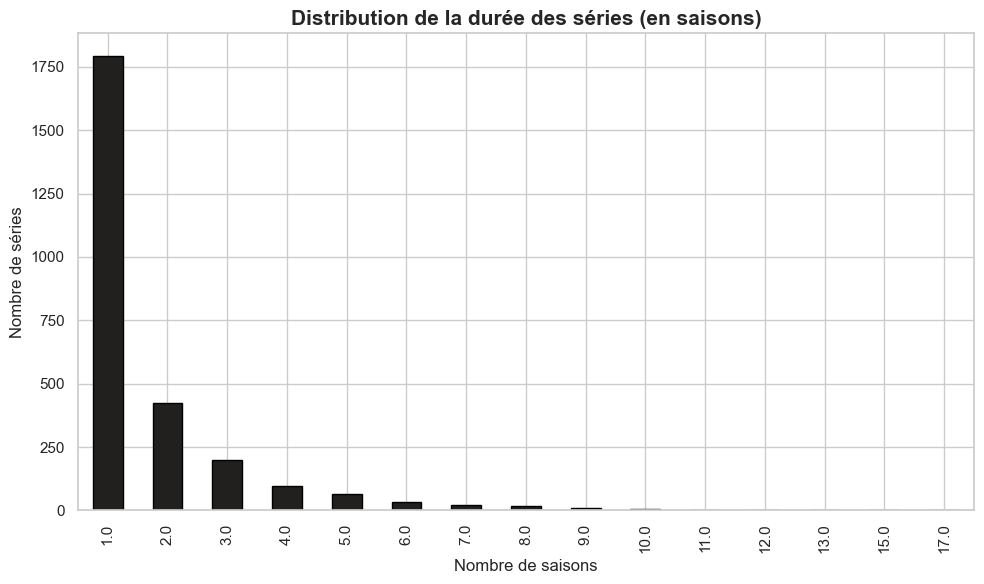

In [61]:
# Question 23f : Répartition de la durée des séries (en saisons)
shows_duration = df[df['type'] == 'TV Show']['duration_clean'].dropna()
plt.figure(figsize=(10, 6))
shows_duration.value_counts().sort_index().plot(kind='bar', color='#221f1f', edgecolor='black')
plt.title('Distribution de la durée des séries (en saisons)', fontsize=15, fontweight='bold')
plt.xlabel('Nombre de saisons')
plt.ylabel('Nombre de séries')
plt.tight_layout()
plt.show()


C:\Users\btyma\AppData\Local\Temp\ipykernel_30796\1931507710.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


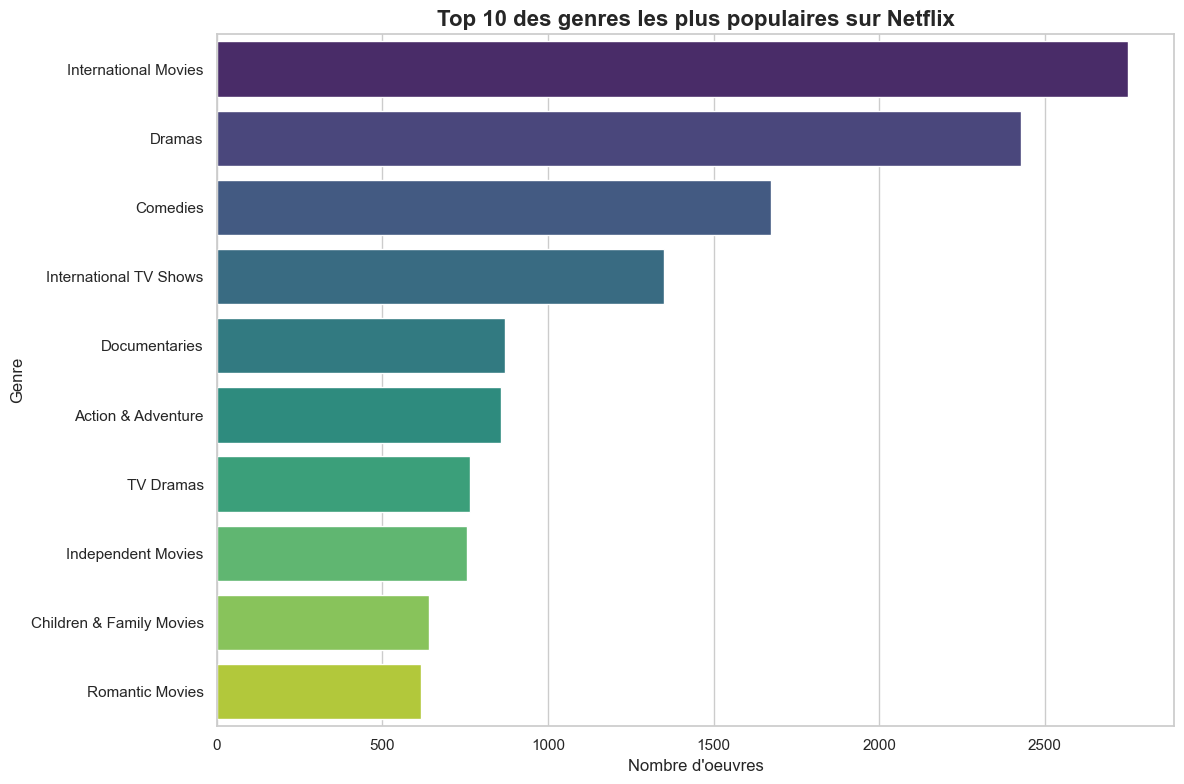

In [62]:
# Question 23g : Répartition des genres d'oeuvres (Top 10)
genres_exploded = df['listed_in'].explode().str.strip()
top_genres = genres_exploded.value_counts().head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 des genres les plus populaires sur Netflix', fontsize=16, fontweight='bold')
plt.xlabel("Nombre d'oeuvres")
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


Top 5 des séries les plus longues :


,title,duration,duration_clean
548,Grey's Anatomy,17 Seasons,17.0
2423,Supernatural,15 Seasons,15.0
4798,NCIS,15 Seasons,15.0
1354,Heartland,13 Seasons,13.0
4220,COMEDIANS of the world,13 Seasons,13.0


C:\Users\btyma\AppData\Local\Temp\ipykernel_30796\2401819291.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_clean', y='title', data=top_series, palette='coolwarm')


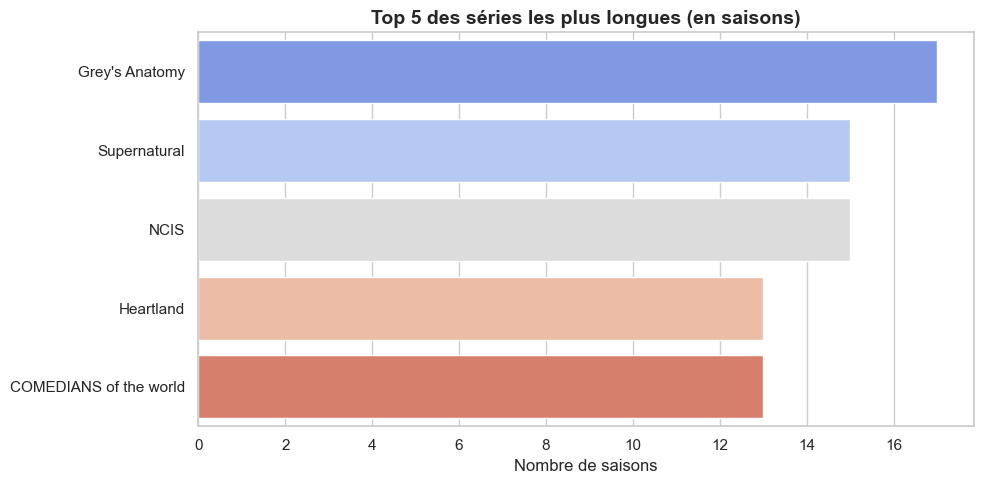

In [63]:
# Question 23h : Top 5 des séries les plus longues
top_series = df[df['type'] == 'TV Show'].nlargest(5, 'duration_clean')[['title', 'duration', 'duration_clean']]
print("Top 5 des séries les plus longues :")
display(top_series)

plt.figure(figsize=(10, 5))
sns.barplot(x='duration_clean', y='title', data=top_series, palette='coolwarm')
plt.title('Top 5 des séries les plus longues (en saisons)', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de saisons')
plt.ylabel('')
plt.tight_layout()
plt.show()


Top 5 des films les plus longs :


,title,duration,duration_clean
4253,Black Mirror: Bandersnatch,312 min,312.0
717,Headspace: Unwind Your Mind,273 min,273.0
2491,The School of Mischief,253 min,253.0
2487,No Longer kids,237 min,237.0
2484,Lock Your Girls In,233 min,233.0


C:\Users\btyma\AppData\Local\Temp\ipykernel_30796\3579471788.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_clean', y='title', data=top_movies, palette='coolwarm')


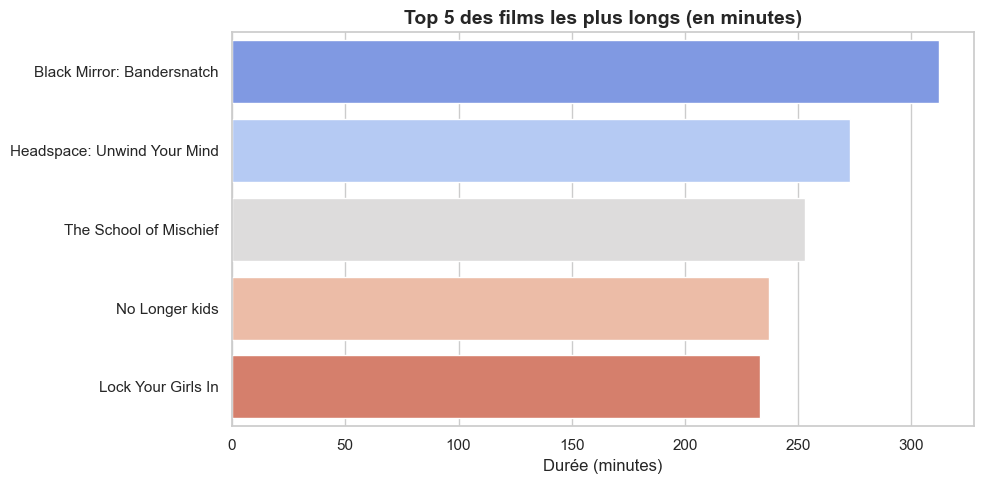

In [64]:
# Question 23i : Top 5 des films les plus longs
top_movies = df[df['type'] == 'Movie'].nlargest(5, 'duration_clean')[['title', 'duration', 'duration_clean']]
print("Top 5 des films les plus longs :")
display(top_movies)

plt.figure(figsize=(10, 5))
sns.barplot(x='duration_clean', y='title', data=top_movies, palette='coolwarm')
plt.title('Top 5 des films les plus longs (en minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Durée (minutes)')
plt.ylabel('')
plt.tight_layout()
plt.show()


C:\Users\btyma\AppData\Local\Temp\ipykernel_30796\204157547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=french_directors.values, y=french_directors.index, palette='Blues_r')


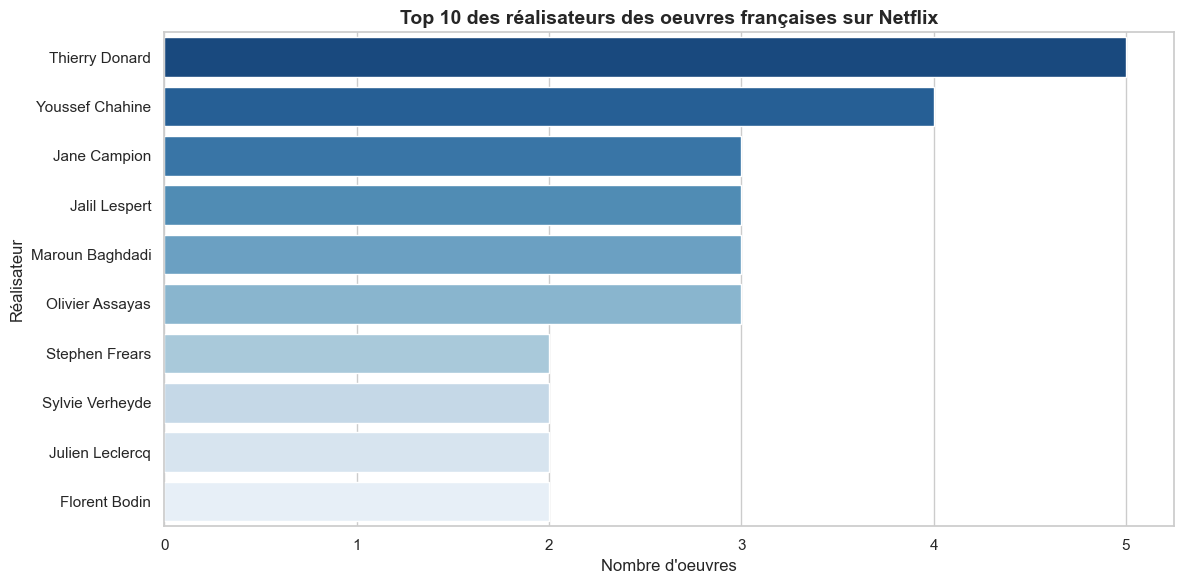

In [65]:
# Question 23j : Répartition des directors des oeuvres françaises
french_works = df[df['country'].str.contains('France', na=False)]
french_directors = french_works['director'].dropna().value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=french_directors.values, y=french_directors.index, palette='Blues_r')
plt.title('Top 10 des réalisateurs des oeuvres françaises sur Netflix', fontsize=14, fontweight='bold')
plt.xlabel("Nombre d'oeuvres")
plt.ylabel('Réalisateur')
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

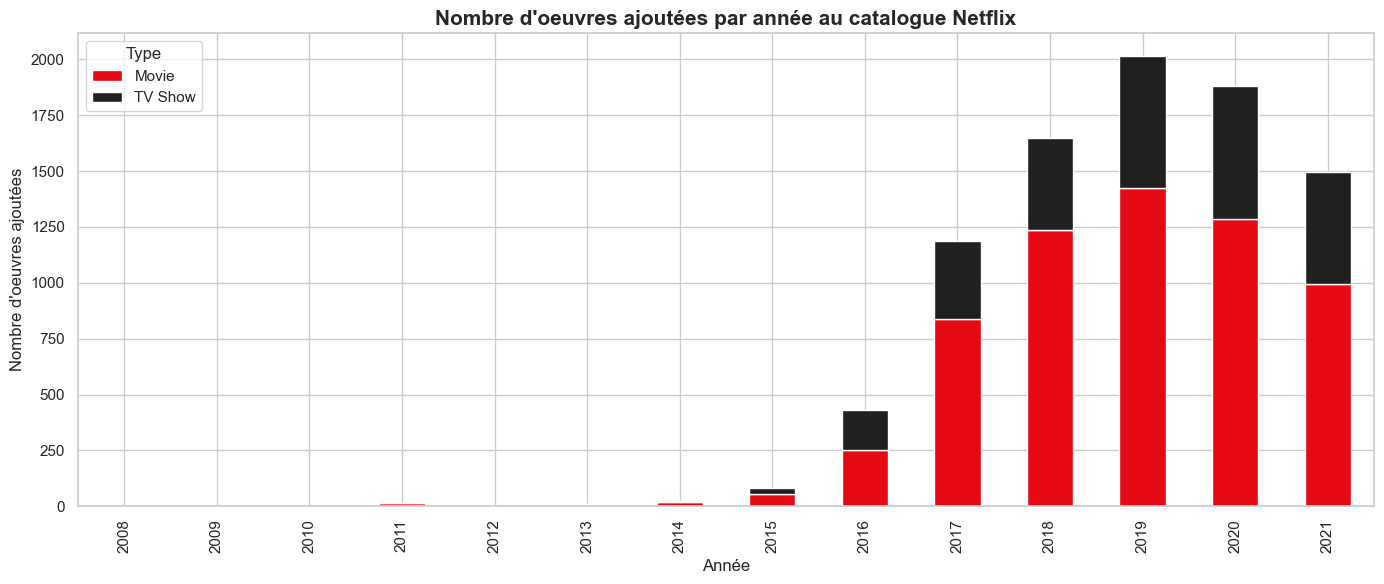

In [66]:
# Question 23k : Répartition des oeuvres en fonction de la date d'ajout
df_added = df.dropna(subset=['date_added']).copy()
df_added['year_added'] = df_added['date_added'].dt.year

plt.figure(figsize=(14, 6))
add_by_year = df_added.groupby(['year_added', 'type']).size().unstack(fill_value=0)
add_by_year.plot(kind='bar', stacked=True, color=['#E50914', '#221f1f'], figsize=(14, 6), edgecolor='white')
plt.title("Nombre d'oeuvres ajoutées par année au catalogue Netflix", fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel("Nombre d'oeuvres ajoutées")
plt.legend(title='Type')
plt.tight_layout()
plt.show()


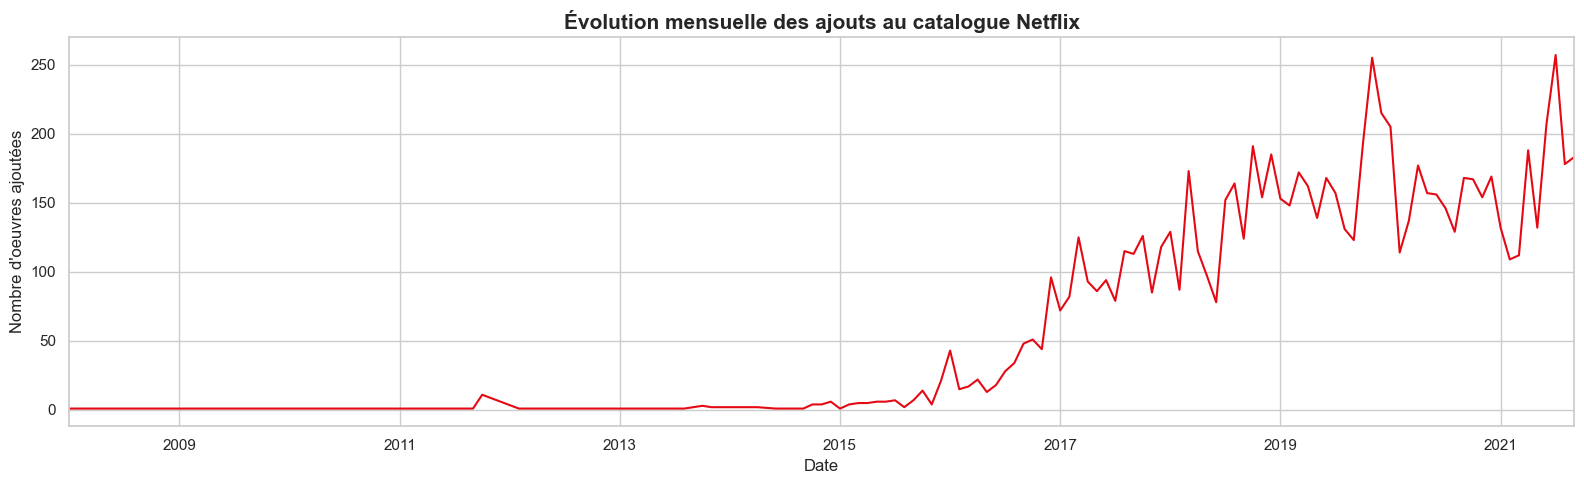

In [67]:
# Question 23l : Graphe supplémentaire — Évolution mensuelle des ajouts
df_added['month_added'] = df_added['date_added'].dt.to_period('M')
monthly = df_added.groupby('month_added').size()

plt.figure(figsize=(16, 5))
monthly.plot(color='#E50914', linewidth=1.5)
plt.title("Évolution mensuelle des ajouts au catalogue Netflix", fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel("Nombre d'oeuvres ajoutées")
plt.tight_layout()
plt.show()


---
## 8. Observations et conclusions

### Question 24 — Analyse des résultats

**Répartition du contenu :**
- Le catalogue Netflix est largement dominé par les films, qui représentent environ 70% du contenu, contre 30% pour les séries TV.

**Tendances géographiques :**
- Les États-Unis dominent massivement la production de contenu sur Netflix, suivis par l'Inde et le Royaume-Uni. La France fait partie du top 10 des pays producteurs.

**Évolution temporelle :**
- Le nombre de contenus ajoutés au catalogue a connu une forte croissance entre 2015 et 2019, avec un pic en 2019. On observe un léger ralentissement en 2020-2021, possiblement lié à la pandémie de COVID-19.

**Ratings :**
- Les ratings les plus fréquents sont TV-MA (contenu pour adultes) et TV-14, ce qui suggère que Netflix cible principalement un public adulte.

**Durée des contenus :**
- La majorité des films durent entre 80 et 120 minutes. Les séries sont majoritairement composées d'une seule saison, ce qui reflète la tendance aux mini-séries et aux séries limitées.

**Genres populaires :**
- Les genres les plus représentés sont les drames internationaux, les comédies et les documentaires. Cela montre la stratégie de Netflix d'offrir un catalogue diversifié et international.

**Réalisateurs :**
- Plusieurs réalisateurs ont produit de nombreuses œuvres pour Netflix, notamment dans le contenu international (Inde, Corée du Sud).

**Conclusion générale :**
Netflix a massivement investi dans l'expansion de son catalogue entre 2015 et 2020, avec une forte orientation vers le contenu international et diversifié. La plateforme privilégie un public adulte tout en maintenant une offre variée en termes de genres et de durées.